In [9]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd


In [10]:
STAT_PATH = "C:/Users/xmelo/AppData/LocalLow/DefaultCompany/_monobeh_boinc"
WORKUNITS_NAME = "workunits.csv"
PARAMS_NAME = "parameters.json"
EXP_NAME = "statistics"


In [11]:
def plot_workunit_completion(ax, file_path, group_size, label):
    df = pd.read_csv(file_path)
    ax.plot(df["timestamp"], df["tasks_inprogress"], label=label)

    threshold_label = f"threshold ({group_size})"
    handles, labels = ax.get_legend_handles_labels()
    if threshold_label in labels:
        ax.axhline(y=group_size, color="r", linestyle="--", label="_nolegend_")
    else:
        ax.axhline(y=group_size, color="r", linestyle="--", label=threshold_label)

    intersection_point = df[df["tasks_inprogress"] <= group_size].head(1)
    if not intersection_point.empty:
        intersection_timestamp = intersection_point["timestamp"].iloc[0]
        intersection_value = intersection_point["tasks_inprogress"].iloc[0]
        ax.plot(intersection_timestamp, intersection_value, "ro", markersize=8)
        ax.axvline(x=intersection_timestamp, color="g", linestyle="-.")

    ax.set_title("Tasks in progress over time")
    ax.set_xlabel("Time")
    ax.set_ylabel("Tasks in progress")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax.legend()


found ['statistics_1']


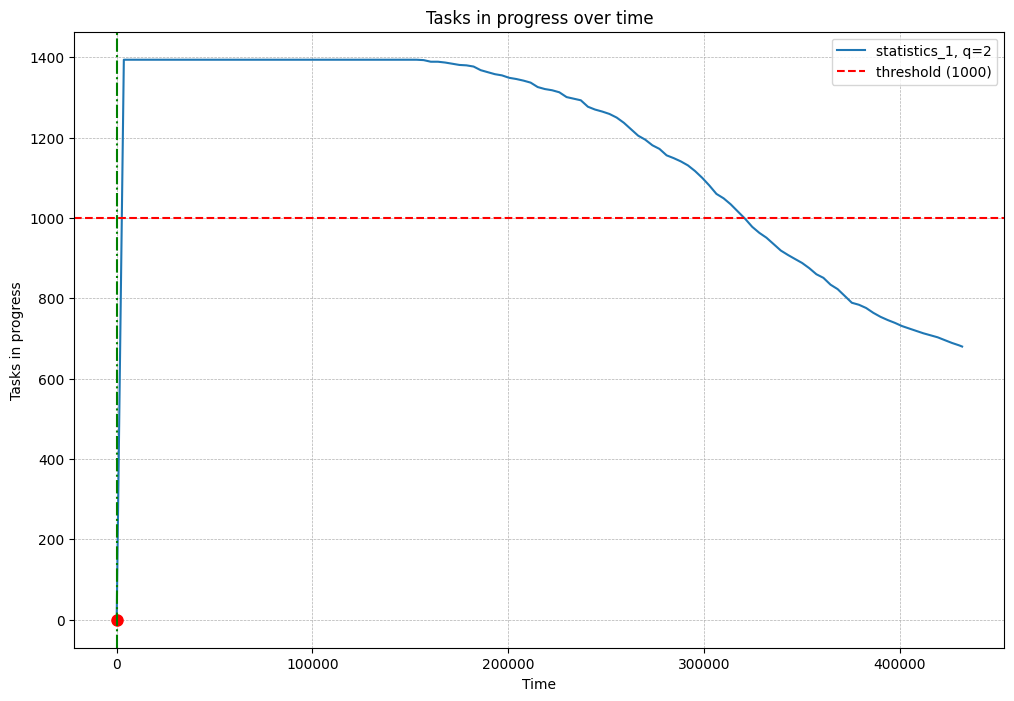

In [12]:
folders = sorted(
    f
    for f in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, f)) and f.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

fig, ax = plt.subplots(figsize=(12, 8))

for folder in folders:
    full_path = os.path.join(STAT_PATH, folder)
    with open(os.path.join(full_path, PARAMS_NAME), "r", encoding="utf-8") as file:
        params = json.load(file)

    group_size = params["GroupConfig"]["NumberOfClients"]
    replication_value = params["ProjectConfig"]["TaskConfigs"][0]["InitialCreatedWorkunits"]
    label = f"{folder}, q={replication_value}"
    plot_workunit_completion(ax, os.path.join(full_path, WORKUNITS_NAME), group_size, label)

plt.show()
